<a href="https://colab.research.google.com/github/YaKhom/ML-Practice/blob/main/LinReg_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Линейная регрессия. Работа с признаками

## Описание задачи и загрузка данных

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

В этом задании мы рассмотрим различные аспекты построения линейной модели. Мы будем работать с одним из классических наборов данных в статистике, содержащим информацию о бриллиантах. Описание можно посмотреть [здесь](https://www.kaggle.com/shivam2503/diamonds).

In [2]:
data = pd.read_csv('https://raw.githubusercontent.com/evgpat/edu_stepik_practical_ml/main/datasets/diamonds.csv')
data.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Посмотрим на типы столбцов.

In [3]:
data.dtypes

,0
Unnamed: 0,int64
carat,float64
cut,object
color,object
clarity,object
depth,float64
table,float64
price,int64
x,float64
y,float64


Мы будем решать задачу предсказания цены бриллианта `price` в зависимости от его характеристик.

## Построение модели

### Задание 1

Есть ли в наборе данных пропущенные значения? Если да, удалите их.

Также выведите на экран число пропусков в каждом столбце.

In [7]:
# your code here
# Количество пропусков
missing_count = data.isna().sum()
print("Количество пропусков по столбцам:")
print(missing_count)

# Процент пропусков
missing_percent = (data.isna().mean() * 100).round(2)
print("\nПроцент пропусков по столбцам:")
print(missing_percent)



Количество пропусков по столбцам:
Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

Процент пропусков по столбцам:
Unnamed: 0    0.0
carat         0.0
cut           0.0
color         0.0
clarity       0.0
depth         0.0
table         0.0
price         0.0
x             0.0
y             0.0
z             0.0
dtype: float64


### Задача 2

Есть ли в наборе данных бессмысленные столбцы (признаки, не несущие дополнительной информации)?  
Если да, то удалите их.

In [10]:
# Удаление бессмысленного столбца-индекса
if 'Unnamed: 0' in data.columns:
    data = data.drop('Unnamed: 0', axis=1)
    print("Столбец 'Unnamed: 0' успешно удален")
else:
    print("Столбец 'Unnamed: 0' не найден в датасете")

# Проверка результата
print(f"\nТекущие столбцы датасета ({len(data.columns)}):")
print(list(data.columns))
print(f"\nРазмер датасета: {data.shape}")

Столбец 'Unnamed: 0' успешно удален

Текущие столбцы датасета (10):
['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']

Размер датасета: (53940, 10)


### Задание 3

Линейная регрессия основана на предположении о линейной связи между признаками и целевой переменной, а потому перед выбором переменных для включения в модель имеет смысл проверить, насколько эта связь выполняется. Для следующих пунктов нам также потребуются корреляции между признаками.  
Выведите матрицу корреляций между всеми вещественными признаками и целевой переменной.

Какой вещественный признак коррелирует с целевой переменной больше всего?

Вещественные признаки в датасете:
['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

Матрица корреляций между вещественными признаками и price:
price    1.000000
carat    0.921591
x        0.884435
y        0.865421
z        0.861249
table    0.127134
depth   -0.010647
Name: price, dtype: float64


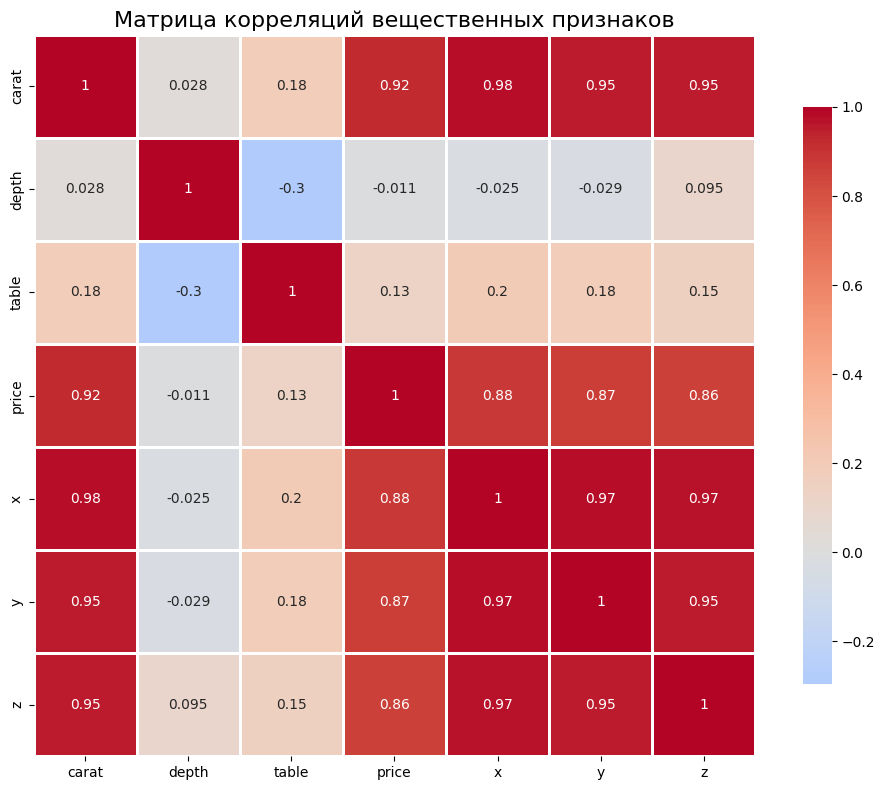


Признак с максимальной корреляцией с price: carat
Корреляция: 0.9216


In [11]:
# Выбираем только вещественные (числовые) признаки
# Исключаем категориальные (cut, color, clarity, clarity_category если они еще есть)
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()

# Убеждаемся, что price включена
if 'price' not in numeric_cols:
    numeric_cols.append('price')

print("Вещественные признаки в датасете:")
print(numeric_cols)

# Строим матрицу корреляций
correlation_matrix = data[numeric_cols].corr()

# Выводим матрицу корреляций
print("\nМатрица корреляций между вещественными признаками и price:")
print(correlation_matrix['price'].sort_values(ascending=False))

# Визуализация для наглядности
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляций вещественных признаков', fontsize=16)
plt.tight_layout()
plt.show()

# Находим признак с максимальной корреляцией с price (исключая саму price)
correlations_with_price = correlation_matrix['price'].drop('price').abs().sort_values(ascending=False)
best_feature = correlations_with_price.index[0]
best_correlation = correlations_with_price.iloc[0]

print(f"\n{'='*50}")
print(f"Признак с максимальной корреляцией с price: {best_feature}")
print(f"Корреляция: {best_correlation:.4f}")
print(f"{'='*50}")

### Задание 4

Так как линейная модель складывает значения признаков с некоторыми весами, нам нужно аккуратно обработать категориальные признаки. Закодируйте категориальные переменные при помощи OneHot-кодирования ([`pd.get_dummies`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html)). Не забудьте поставить значение параметра `drop_first` равным `True`.

Сколько получилось столбцов в таблице `data`?

*P.S. Числовые столбцы оставляем в таблице без изменений.*

In [12]:
print("Исходная информация о датасете:")
print(f"Исходное количество столбцов: {data.shape[1]}")
print(f"Исходное количество строк: {data.shape[0]}")
print("\nТипы столбцов:")
print(data.dtypes)
print("\n" + "="*50)

# Определяем категориальные столбцы
# В датасете с бриллиантами категориальными обычно являются:
# cut, color, clarity (и возможно clarity_category, если он еще есть)
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
print(f"Категориальные столбцы для OneHot-кодирования: {categorical_cols}")

# Применяем OneHot-кодирование с drop_first=True
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

print("\n" + "="*50)
print(f"Количество столбцов после OneHot-кодирования: {data_encoded.shape[1]}")
print(f"Количество строк после OneHot-кодирования: {data_encoded.shape[0]}")
print("\nСписок всех столбцов после кодирования:")
print(list(data_encoded.columns))

# Подробная статистика по категориальным переменным
print("\n" + "="*50)
print("Детализация по категориальным переменным:")
for col in categorical_cols:
    unique_values = data[col].nunique()
    new_cols = [c for c in data_encoded.columns if c.startswith(col + '_')]
    print(f"{col}: {unique_values} уникальных значений -> {len(new_cols)} новых столбцов")

# Сохраняем результат обратно в переменную data (если нужно)
data = data_encoded

print("\n" + "="*50)
print(f"ИТОГО: {data.shape[1]} столбцов в таблице data")

Исходная информация о датасете:
Исходное количество столбцов: 10
Исходное количество строк: 53940

Типы столбцов:
carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

Категориальные столбцы для OneHot-кодирования: ['cut', 'color', 'clarity']

Количество столбцов после OneHot-кодирования: 24
Количество строк после OneHot-кодирования: 53940

Список всех столбцов после кодирования:
['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'cut_Good', 'cut_Ideal', 'cut_Premium', 'cut_Very Good', 'color_E', 'color_F', 'color_G', 'color_H', 'color_I', 'color_J', 'clarity_IF', 'clarity_SI1', 'clarity_SI2', 'clarity_VS1', 'clarity_VS2', 'clarity_VVS1', 'clarity_VVS2']

Детализация по категориальным переменным:
cut: 5 уникальных значений -> 4 новых столбцов
color: 7 уникальных значений -> 6 новых столбцов
clarity: 8 уникальных значений -> 7 новых стол

### Задание 5

Создайте матрицу `X`, содержащую все признаки, и не содержащую целевую переменную `price`. Также создайте вектор `y`, содержащий целевую переменную `price`.

In [14]:
# your code here
# Создаем матрицу X (все признаки кроме price)
X = data.drop('price', axis=1)

# Создаем вектор y (только цена)
y = data['price']

# Проверка результатов
print("Информация о матрице признаков X:")
print(f"Размерность X: {X.shape}")
print(f"Количество признаков: {X.shape[1]}")
print(f"Количество наблюдений: {X.shape[0]}")
print("\nПервые 5 строк X:")
print(X.head())

print("\n" + "="*50)
print("Информация о векторе целевой переменной y:")
print(f"Размерность y: {y.shape}")
print(f"Тип данных y: {y.dtype}")
print(f"Статистика цен:")
print(f"Минимальная цена: {y.min()}")
print(f"Максимальная цена: {y.max()}")
print(f"Средняя цена: {y.mean():.2f}")
print(f"Медианная цена: {y.median():.2f}")
print("\nПервые 5 значений y:")
print(y.head())

print("\n" + "="*50)
print("Проверка соответствия:")
print(f"X содержит {X.shape[1]} признаков")
print(f"Все признаки (кроме price): {list(X.columns)}")
print(f"y содержит цены для {len(y)} бриллиантов")


Информация о матрице признаков X:
Размерность X: (53940, 23)
Количество признаков: 23
Количество наблюдений: 53940

Первые 5 строк X:
   carat  depth  table     x     y     z  cut_Good  cut_Ideal  cut_Premium  \
0   0.23   61.5   55.0  3.95  3.98  2.43     False       True        False   
1   0.21   59.8   61.0  3.89  3.84  2.31     False      False         True   
2   0.23   56.9   65.0  4.05  4.07  2.31      True      False        False   
3   0.29   62.4   58.0  4.20  4.23  2.63     False      False         True   
4   0.31   63.3   58.0  4.34  4.35  2.75      True      False        False   

   cut_Very Good  ...  color_H  color_I  color_J  clarity_IF  clarity_SI1  \
0          False  ...    False    False    False       False        False   
1          False  ...    False    False    False       False         True   
2          False  ...    False    False    False       False        False   
3          False  ...    False     True    False       False        False   
4          F

Разделите выборку на тренировочную и тестовую. Долю тестовой выборки укажите равной `0.3`.

При разбиении укажите `random_state = 42`.

In [16]:
from sklearn.model_selection import train_test_split

# Разделение выборки на тренировочную и тестовую
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,      # 30% данных отводим на тестовую выборку
    random_state=42     # фиксируем seed для воспроизводимости
)

# Проверка результатов разделения
print("Результаты разделения данных:")
print("=" * 40)
print(f"Общий размер выборки: {len(X)}")
print(f"Размер тренировочной выборки (X_train): {X_train.shape}")
print(f"Размер тестовой выборки (X_test): {X_test.shape}")
print(f"Размер тренировочной выборки (y_train): {y_train.shape}")
print(f"Размер тестовой выборки (y_test): {y_test.shape}")

print("\nПроверка пропорций:")
train_ratio = len(X_train) / len(X) * 100
test_ratio = len(X_test) / len(X) * 100
print(f"Тренировочная выборка: {train_ratio:.1f}%")
print(f"Тестовая выборка: {test_ratio:.1f}%")

print("\nПервые несколько значений из тренировочной выборки:")
print("Цены (y_train):", y_train.head().values)
print("\nПервые несколько значений из тестовой выборки:")
print("Цены (y_test):", y_test.head().values)

# Дополнительная проверка распределения
print("\nСтатистика по целевой переменной в разных выборках:")
print("Тренировочная выборка - средняя цена:", y_train.mean().round(2))
print("Тестовая выборка - средняя цена:", y_test.mean().round(2))
print("Полная выборка - средняя цена:", y.mean().round(2))

Результаты разделения данных:
Общий размер выборки: 53940
Размер тренировочной выборки (X_train): (37758, 23)
Размер тестовой выборки (X_test): (16182, 23)
Размер тренировочной выборки (y_train): (37758,)
Размер тестовой выборки (y_test): (16182,)

Проверка пропорций:
Тренировочная выборка: 70.0%
Тестовая выборка: 30.0%

Первые несколько значений из тренировочной выборки:
Цены (y_train): [ 8131   756 10351  2795  4092]

Первые несколько значений из тестовой выборки:
Цены (y_test): [ 559 2201 1238 1304 6901]

Статистика по целевой переменной в разных выборках:
Тренировочная выборка - средняя цена: 3951.5
Тестовая выборка - средняя цена: 3889.18
Полная выборка - средняя цена: 3932.8


### Задание 6

Зачастую при использовании линейных моделей вещественные признаки масштабируются.  В этой задаче масштабируйте вещественные признаки тренировочной и тестовой выборок при помощи модуля `StandardScaler`.

*  Обучите (`fit`) scaler на тренировочных данных
*  Преобразуйте (`transform`) и трейн, и тест

После применения масштабирования матрица перестает быть объектом `pandas.DataFrame` - решите эту проблему.

In [17]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Определяем вещественные (числовые) признаки, которые нужно масштабировать
# Это исходные числовые признаки (не one-hot закодированные категориальные)
# Обычно это: carat, depth, table, x, y, z

# Получаем список всех числовых колонок
all_numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Исключаем бинарные признаки (one-hot encoded), которые обычно имеют значения 0/1
# Бинарные признаки обычно не масштабируют, чтобы сохранить интерпретируемость
# Определяем их как колонки с уникальными значениями {0, 1}
binary_cols = []
continuous_cols = []

for col in all_numeric_cols:
    unique_values = X_train[col].unique()
    if set(unique_values).issubset({0, 1}):
        binary_cols.append(col)
    else:
        continuous_cols.append(col)

print("Вещественные признаки для масштабирования (continuous):")
print(continuous_cols)
print(f"\nКоличество вещественных признаков: {len(continuous_cols)}")

print("\nБинарные признаки (one-hot encoded), которые НЕ масштабируем:")
print(binary_cols)
print(f"Количество бинарных признаков: {len(binary_cols)}")

# Создаем и обучаем scaler только на вещественных признаках тренировочной выборки
scaler = StandardScaler()
scaler.fit(X_train[continuous_cols])

# Применяем масштабирование к тренировочной и тестовой выборкам
X_train_scaled_array = scaler.transform(X_train[continuous_cols])
X_test_scaled_array = scaler.transform(X_test[continuous_cols])

# Преобразуем обратно в DataFrame с сохранением индексов и названий колонок
X_train_scaled = pd.DataFrame(
    X_train_scaled_array,
    columns=continuous_cols,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled_array,
    columns=continuous_cols,
    index=X_test.index
)

# Добавляем обратно бинарные признаки (one-hot encoded)
# Сначала удаляем исходные непрерывные признаки из исходных DataFrame
X_train_original = X_train.drop(columns=continuous_cols)
X_test_original = X_test.drop(columns=continuous_cols)

# Объединяем масштабированные признаки с бинарными
X_train_final = pd.concat([X_train_scaled, X_train_original], axis=1)
X_test_final = pd.concat([X_test_scaled, X_test_original], axis=1)

# Восстанавливаем порядок колонок (чтобы сохранить структуру)
X_train_final = X_train_final[X_train.columns]
X_test_final = X_test_final[X_test.columns]

# Проверка результатов
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ МАСШТАБИРОВАНИЯ:")
print("="*60)

print(f"\nТип X_train_final: {type(X_train_final)}")
print(f"Размерность X_train_final: {X_train_final.shape}")
print(f"Размерность X_test_final: {X_test_final.shape}")

print("\nСтатистика ДО масштабирования (первые 5 признаков):")
for col in continuous_cols[:5]:
    print(f"{col}: среднее={X_train[col].mean():.4f}, стд={X_train[col].std():.4f}")

print("\nСтатистика ПОСЛЕ масштабирования (тренировочная выборка):")
for col in continuous_cols[:5]:
    print(f"{col}: среднее={X_train_final[col].mean():.6f}, стд={X_train_final[col].std():.6f}")

print("\nСтатистика ПОСЛЕ масштабирования (тестовая выборка):")
for col in continuous_cols[:5]:
    print(f"{col}: среднее={X_test_final[col].mean():.6f}, стд={X_test_final[col].std():.6f}")

print("\nПервые 5 строк масштабированной тренировочной выборки:")
print(X_train_final.head())

print("\nПервые 5 строк масштабированной тестовой выборки:")
print(X_test_final.head())

# Сохраняем финальные данные для дальнейшего использования
# X_train = X_train_final
# X_test = X_test_final

Вещественные признаки для масштабирования (continuous):
['carat', 'depth', 'table', 'x', 'y', 'z']

Количество вещественных признаков: 6

Бинарные признаки (one-hot encoded), которые НЕ масштабируем:
[]
Количество бинарных признаков: 0

РЕЗУЛЬТАТЫ МАСШТАБИРОВАНИЯ:

Тип X_train_final: <class 'pandas.core.frame.DataFrame'>
Размерность X_train_final: (37758, 23)
Размерность X_test_final: (16182, 23)

Статистика ДО масштабирования (первые 5 признаков):
carat: среднее=0.7998, стд=0.4756
depth: среднее=61.7449, стд=1.4286
table: среднее=57.4611, стд=2.2266
x: среднее=5.7354, стд=1.1223
y: среднее=5.7388, стд=1.1466

Статистика ПОСЛЕ масштабирования (тренировочная выборка):
carat: среднее=0.000000, стд=1.000013
depth: среднее=0.000000, стд=1.000013
table: среднее=0.000000, стд=1.000013
x: среднее=0.000000, стд=1.000013
y: среднее=-0.000000, стд=1.000013

Статистика ПОСЛЕ масштабирования (тестовая выборка):
carat: среднее=-0.012780, стд=0.989119
depth: среднее=0.010458, стд=1.009289
table: сре

### Задание 7

Обучите линейную регрессию на тренировочной выборке. Выведите *r2-score* на тренировочной и тестовой выборках.

РЕЗУЛЬТАТЫ ЛИНЕЙНОЙ РЕГРЕССИИ

R² на тренировочной выборке: 0.919598
R² на тестовой выборке: 0.920187

ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ О МОДЕЛИ

Количество признаков: 23
Свободный член (intercept): -261.3851

Топ-10 самых важных признаков (по абсолютному значению коэффициента):
     feature  coefficient
  clarity_IF  5459.037300
       carat  5338.615671
clarity_VVS1  5101.335181
clarity_VVS2  5028.295530
 clarity_VS1  4657.834307
 clarity_VS2  4336.725583
 clarity_SI1  3751.709671
 clarity_SI2  2781.940548
     color_J -2381.989788
     color_I -1476.084233

АНАЛИЗ КАЧЕСТВА МОДЕЛИ

MAE на тренировочной выборке: 746.03
MAE на тестовой выборке: 734.24
RMSE на тренировочной выборке: 1136.02
RMSE на тестовой выборке: 1115.69

Разница между R² train и test: -0.000589
✅ Модель не переобучена (разница в допустимых пределах)


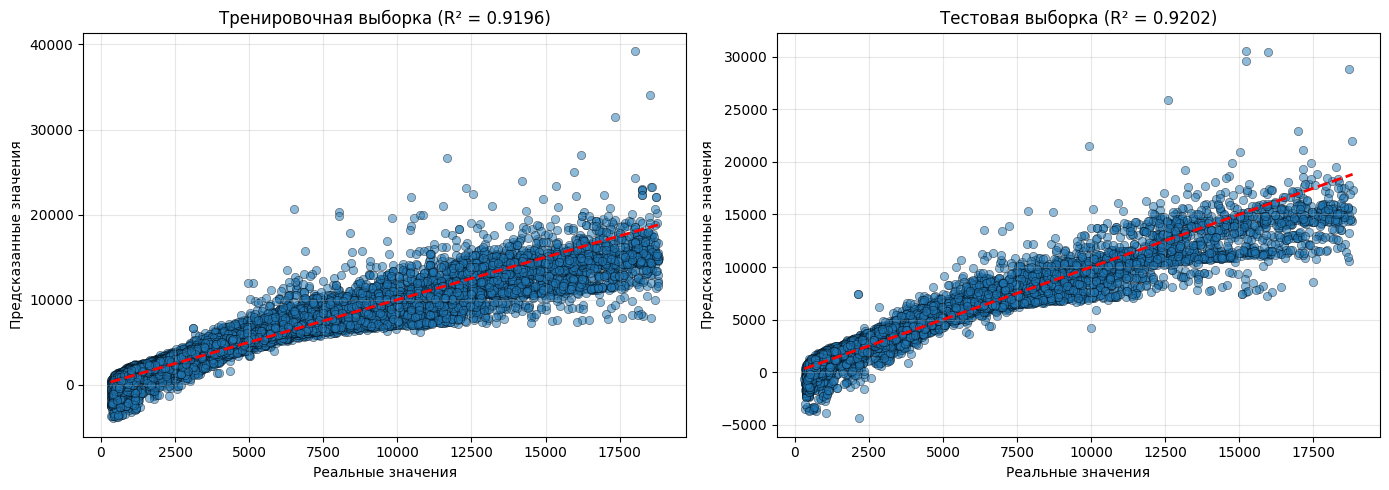

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Создаем и обучаем модель линейной регрессии
model = LinearRegression()
model.fit(X_train_final, y_train)

# Делаем предсказания
y_train_pred = model.predict(X_train_final)
y_test_pred = model.predict(X_test_final)

# Вычисляем R² для тренировочной и тестовой выборок
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

# Вывод результатов
print("="*60)
print("РЕЗУЛЬТАТЫ ЛИНЕЙНОЙ РЕГРЕССИИ")
print("="*60)

print(f"\nR² на тренировочной выборке: {r2_train:.6f}")
print(f"R² на тестовой выборке: {r2_test:.6f}")

print("\n" + "="*60)
print("ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ О МОДЕЛИ")
print("="*60)

# Коэффициенты модели
print(f"\nКоличество признаков: {len(model.coef_)}")
print(f"Свободный член (intercept): {model.intercept_:.4f}")

# Выводим топ-10 самых важных признаков (по абсолютному значению коэффициента)
feature_importance = pd.DataFrame({
    'feature': X_train_final.columns,
    'coefficient': model.coef_
})
feature_importance['abs_coef'] = np.abs(feature_importance['coefficient'])
feature_importance = feature_importance.sort_values('abs_coef', ascending=False)

print("\nТоп-10 самых важных признаков (по абсолютному значению коэффициента):")
print(feature_importance[['feature', 'coefficient']].head(10).to_string(index=False))

# Анализ качества модели
print("\n" + "="*60)
print("АНАЛИЗ КАЧЕСТВА МОДЕЛИ")
print("="*60)

# Вычисляем дополнительные метрики
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"\nMAE на тренировочной выборке: {mae_train:.2f}")
print(f"MAE на тестовой выборке: {mae_test:.2f}")
print(f"RMSE на тренировочной выборке: {rmse_train:.2f}")
print(f"RMSE на тестовой выборке: {rmse_test:.2f}")

# Проверка на переобучение
overfitting = r2_train - r2_test
print(f"\nРазница между R² train и test: {overfitting:.6f}")

if overfitting > 0.05:
    print("⚠️  Возможно переобучение (разница > 0.05)")
elif overfitting < -0.05:
    print("⚠️  Аномалия: тест работает лучше трейна (возможно проблема с данными)")
else:
    print("✅ Модель не переобучена (разница в допустимых пределах)")

# Визуализация предсказаний vs реальных значений (опционально)
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Тренировочная выборка
    axes[0].scatter(y_train, y_train_pred, alpha=0.5, edgecolors='black', linewidth=0.5)
    axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
    axes[0].set_xlabel('Реальные значения')
    axes[0].set_ylabel('Предсказанные значения')
    axes[0].set_title(f'Тренировочная выборка (R² = {r2_train:.4f})')
    axes[0].grid(True, alpha=0.3)

    # Тестовая выборка
    axes[1].scatter(y_test, y_test_pred, alpha=0.5, edgecolors='black', linewidth=0.5)
    axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[1].set_xlabel('Реальные значения')
    axes[1].set_ylabel('Предсказанные значения')
    axes[1].set_title(f'Тестовая выборка (R² = {r2_test:.4f})')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

except ImportError:
    print("\nДля визуализации установите matplotlib: pip install matplotlib")
except Exception as e:
    print(f"\nНе удалось создать визуализацию: {e}")

### Задание 8

Выведите на экран веса, которые линейная регрессия присвоила признакам.

Какой признак имеет наибольший отрицательный вес? (наибольший по модулю среди всех отрицательных весов)

ВЕСА (КОЭФФИЦИЕНТЫ) ЛИНЕЙНОЙ РЕГРЕССИИ

Все признаки с их весами (отсортировано по абсолютному значению):
      feature       weight
   clarity_IF  5459.037300
        carat  5338.615671
 clarity_VVS1  5101.335181
 clarity_VVS2  5028.295530
  clarity_VS1  4657.834307
  clarity_VS2  4336.725583
  clarity_SI1  3751.709671
  clarity_SI2  2781.940548
      color_J -2381.989788
      color_I -1476.084233
            x -1100.418850
      color_H  -998.634669
    cut_Ideal   846.196258
  cut_Premium   777.769963
cut_Very Good   743.301360
     cut_Good   595.521080
      color_G  -500.160238
      color_F  -273.303976
      color_E  -217.028968
        depth   -90.173817
        table   -60.332280
            z   -34.258945
            y    -6.458917

ТОП-10 ПРИЗНАКОВ С НАИБОЛЬШИМИ ВЕСАМИ (ПО МОДУЛЮ):
     feature       weight
  clarity_IF  5459.037300
       carat  5338.615671
clarity_VVS1  5101.335181
clarity_VVS2  5028.295530
 clarity_VS1  4657.834307
 clarity_VS2  4336.725583
 clarity_SI1

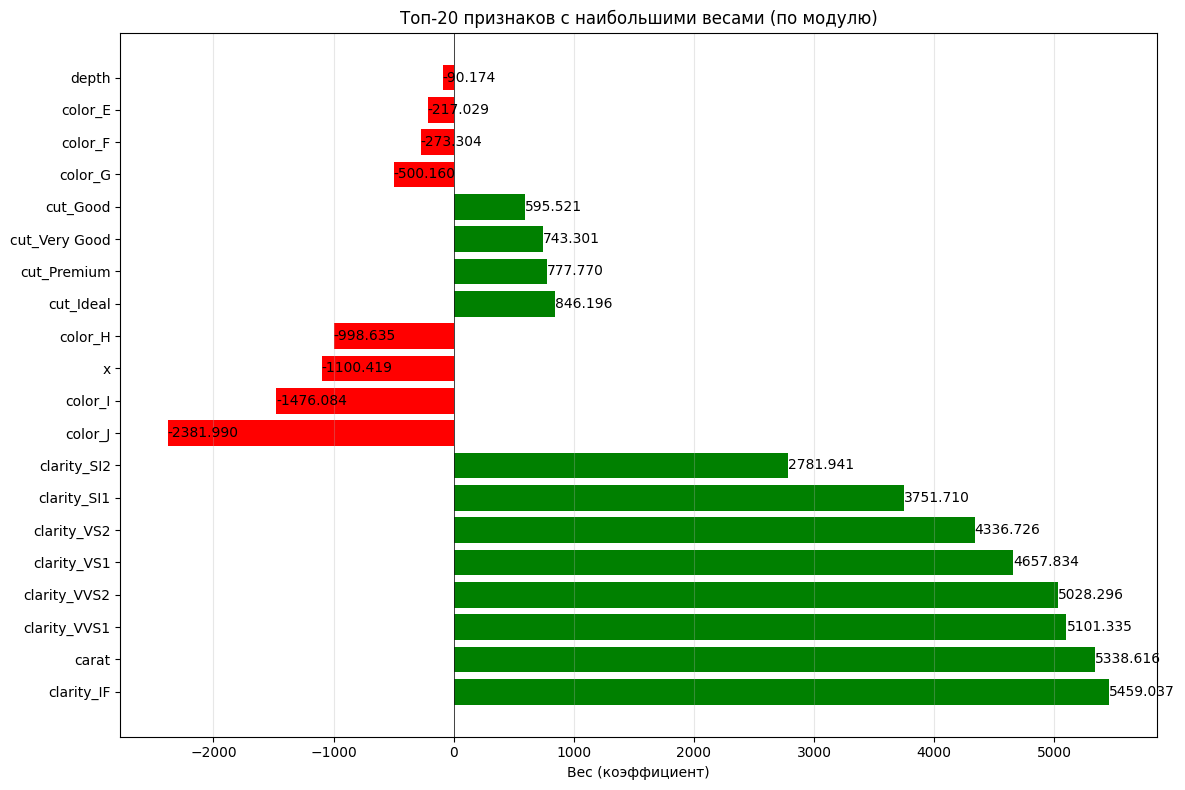

In [19]:
# Создаем DataFrame с признаками и их весами
weights_df = pd.DataFrame({
    'feature': X_train_final.columns,
    'weight': model.coef_
})

# Добавляем абсолютное значение веса для сортировки
weights_df['abs_weight'] = np.abs(weights_df['weight'])

# Сортируем по абсолютному значению веса (от большего к меньшему)
weights_df_sorted = weights_df.sort_values('abs_weight', ascending=False)

print("="*80)
print("ВЕСА (КОЭФФИЦИЕНТЫ) ЛИНЕЙНОЙ РЕГРЕССИИ")
print("="*80)
print("\nВсе признаки с их весами (отсортировано по абсолютному значению):")
print(weights_df_sorted[['feature', 'weight']].to_string(index=False))

print("\n" + "="*80)
print("ТОП-10 ПРИЗНАКОВ С НАИБОЛЬШИМИ ВЕСАМИ (ПО МОДУЛЮ):")
print("="*80)
print(weights_df_sorted[['feature', 'weight']].head(10).to_string(index=False))

# Находим признаки с отрицательными весами
negative_weights = weights_df[weights_df['weight'] < 0].copy()
negative_weights['abs_weight'] = np.abs(negative_weights['weight'])
negative_weights_sorted = negative_weights.sort_values('abs_weight', ascending=False)

print("\n" + "="*80)
print("ПРИЗНАКИ С ОТРИЦАТЕЛЬНЫМИ ВЕСАМИ:")
print("="*80)
if len(negative_weights_sorted) > 0:
    print(negative_weights_sorted[['feature', 'weight']].to_string(index=False))

    # Находим признак с наибольшим отрицательным весом (по модулю)
    max_negative = negative_weights_sorted.iloc[0]

    print("\n" + "="*80)
    print("ОТВЕТ НА ВОПРОС:")
    print("="*80)
    print(f"Признак с НАИБОЛЬШИМ ОТРИЦАТЕЛЬНЫМ ВЕСОМ: '{max_negative['feature']}'")
    print(f"Вес: {max_negative['weight']:.6f}")
    print(f"Абсолютное значение: {max_negative['abs_weight']:.6f}")
else:
    print("Нет признаков с отрицательными весами")

print("\n" + "="*80)
print("СТАТИСТИКА ПО ВЕСАМ:")
print("="*80)
print(f"Всего признаков: {len(weights_df)}")
print(f"Положительных весов: {(weights_df['weight'] > 0).sum()}")
print(f"Отрицательных весов: {(weights_df['weight'] < 0).sum()}")
print(f"Нулевых весов: {(weights_df['weight'] == 0).sum()}")
print(f"Максимальный вес: {weights_df['weight'].max():.6f}")
print(f"Минимальный вес: {weights_df['weight'].min():.6f}")
print(f"Средний вес: {weights_df['weight'].mean():.6f}")

# Дополнительно: визуализация топ-20 весов
try:
    import matplotlib.pyplot as plt

    # Берем топ-20 признаков по абсолютному значению
    top20 = weights_df_sorted.head(20).copy()

    # Разделяем положительные и отрицательные для цвета
    colors = ['red' if w < 0 else 'green' for w in top20['weight']]

    plt.figure(figsize=(12, 8))
    plt.barh(range(len(top20)), top20['weight'].values, color=colors)
    plt.yticks(range(len(top20)), top20['feature'].values)
    plt.xlabel('Вес (коэффициент)')
    plt.title('Топ-20 признаков с наибольшими весами (по модулю)')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.grid(True, alpha=0.3, axis='x')

    # Добавляем значения весов на график
    for i, v in enumerate(top20['weight'].values):
        plt.text(v, i, f'{v:.3f}', va='center')

    plt.tight_layout()
    plt.show()

except ImportError:
    pass

## Попытка улучшить качество модели

Данная часть является творческой, и задания в ней немного сложнее, чем предыдущие.

Следующие вопросы не проверяются тестами.

### Задание 9

Как можно заметить из анализа корреляционной матрицы в задании 3, между некоторыми признаками имеется сильная корреляция, что может быть индикатором проблемы *мультиколлинеарности*. Различия в порядке коэффициентов, выявленные в предыдущей задаче, также свидетельствуют об этом. Для решения этой проблемы можно либо исключить некоторые признаки из модели (например, если признак линейно зависим с какими-то другими, его можно исключить из модели, т.е. удалить из матрицы объект-признак и заново обучить модель).

Удалите из матриц `Xtrain` и `Xtest` признак, который наиболее сильно коррелирует с остальными. Заново обучите модель и оцените её качество. Улучшилось ли качество модели?

Попробуйте удалить какой-то другой признак (можете попробовать несколько вариантов). Помогло ли это улучшить качество модели?

In [ ]:
# your code here

### Задание 10

Иногда генерация новых признаков помогает модели лучше находить взаимосвязи между целевой переменной и признаками. Попробуйте придумать новые признаки и добавить их в модель.  

Помогло ли это улучшить качество модели?

In [ ]:
# your code here